In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Tải dữ liệu 

In [2]:
df = pd.read_csv("Ecommerce_Consumer_Behavior_Analysis_Data.csv")

In [3]:
df.head(5)

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


# Hiểu bài toán 

## Mô tả sơ lược dữ liệu liên quan 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

## Mô tả thông kê cơ bản của dataframe

In [5]:
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


## Kiểm tra giá trị NULL

In [6]:
df.isnull().sum()

Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

# Phân tích mô tả

## Thống kê biến đầu vào 

In [9]:
import pandas as pd

# Tạo bảng tổng hợp tất cả biến định tính
categorical_vars = ['Gender', 'Income_Level']

print("\n" + "="*80)
print("BẢNG TỔNG HỢP TẤT CẢ BIẾN ĐỊNH TÍNH")
print("="*80)

for var in categorical_vars:
    print(f"\n【 {var} 】")
    print("-" * 50)
    
    # Tạo bảng
    freq_table = df[var].value_counts().reset_index()
    freq_table.columns = ['Nhóm', 'Số lượng']
    freq_table['Tỷ lệ (%)'] = (freq_table['Số lượng'] / freq_table['Số lượng'].sum() * 100).round(2)
    
    # In bảng
    print(freq_table.to_string(index=False))
    print(f"\n  → Tổng: {freq_table['Số lượng'].sum()} quan sát")


BẢNG TỔNG HỢP TẤT CẢ BIẾN ĐỊNH TÍNH

【 Gender 】
--------------------------------------------------
       Nhóm  Số lượng  Tỷ lệ (%)
     Female       452       45.2
       Male       449       44.9
   Bigender        20        2.0
    Agender        19        1.9
Genderfluid        17        1.7
 Non-binary        16        1.6
 Polygender        15        1.5
Genderqueer        12        1.2

  → Tổng: 1000 quan sát

【 Income_Level 】
--------------------------------------------------
  Nhóm  Số lượng  Tỷ lệ (%)
  High       515       51.5
Middle       485       48.5

  → Tổng: 1000 quan sát


### Biến định lượng
| Tên biến                                | Ý nghĩa                                                          |
| --------------------------------------- | ---------------------------------------------------------------- |
| `Age`                                   | Tuổi của khách hàng                                              |
| `Frequency_of_Purchase`                 | Tần suất mua hàng                                                |
| `Brand_Loyalty`                         | Mức độ trung thành với thương hiệu (theo thang điểm)             |
| `Product_Rating`                        | Đánh giá sản phẩm (thang điểm)                                   |
| `Time_Spent_on_Product_Research(hours)` | Thời gian khách hàng tìm hiểu sản phẩm                           |
| `Return_Rate`                           | Tỷ lệ trả hàng                                                   |
| `Customer_Satisfaction`                 | Mức độ hài lòng của khách hàng                                   |
| `Time_to_Decision`                      | Thời gian khách hàng ra quyết định mua (tính bằng phút hoặc giờ) |

---

### Biến định tính
| Tên biến                   | Ý nghĩa                                                   |
| -------------------------- | --------------------------------------------------------- |
| `Customer_ID`              | Mã khách hàng                                             |
| `Gender`                   | Giới tính                                                 |
| `Income_Level`             | Mức thu nhập                                              |
| `Marital_Status`           | Tình trạng hôn nhân                                       |
| `Education_Level`          | Trình độ học vấn                                          |
| `Occupation`               | Nghề nghiệp                                               |
| `Location`                 | Vị trí địa lý                                             |
| `Purchase_Category`        | Danh mục sản phẩm                                         |
| `Purchase_Channel`         | Kênh mua hàng (online, mobile app, website, v.v.)         |
| `Social_Media_Influence`   | Mức độ ảnh hưởng của mạng xã hội                          |
| `Discount_Sensitivity`     | Độ nhạy cảm với khuyến mãi                                |
| `Engagement_with_Ads`      | Mức độ tương tác với quảng cáo                            |
| `Device_Used_for_Shopping` | Thiết bị sử dụng để mua hàng                              |
| `Payment_Method`           | Phương thức thanh toán                                    |
| `Time_of_Purchase`         | Thời điểm mua hàng (ngày/tháng/năm)                       |
| `Purchase_Intent`          | Mục đích mua hàng (Need-based, Wants-based, Impulsive, …) |
| `Shipping_Preference`      | Hình thức giao hàng                                       |

---

### Biến nhị phân
| Tên biến                          | Ý nghĩa                                                         |
| --------------------------------- | --------------------------------------------------------------- |
| `Discount_Used`                   | Có sử dụng mã giảm giá hay không                                |
| `Customer_Loyalty_Program_Member` | Có phải thành viên chương trình khách hàng thân thiết hay không |


## Trực quan hoá dữ liệu 

### Xem phân bổ dữ liệu định lượng của tập dữ liệu để xem có giá trị ngoại lai hay không 

Các cột định lượng được vẽ là:
['Age', 'Frequency_of_Purchase', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Return_Rate', 'Customer_Satisfaction', 'Time_to_Decision']


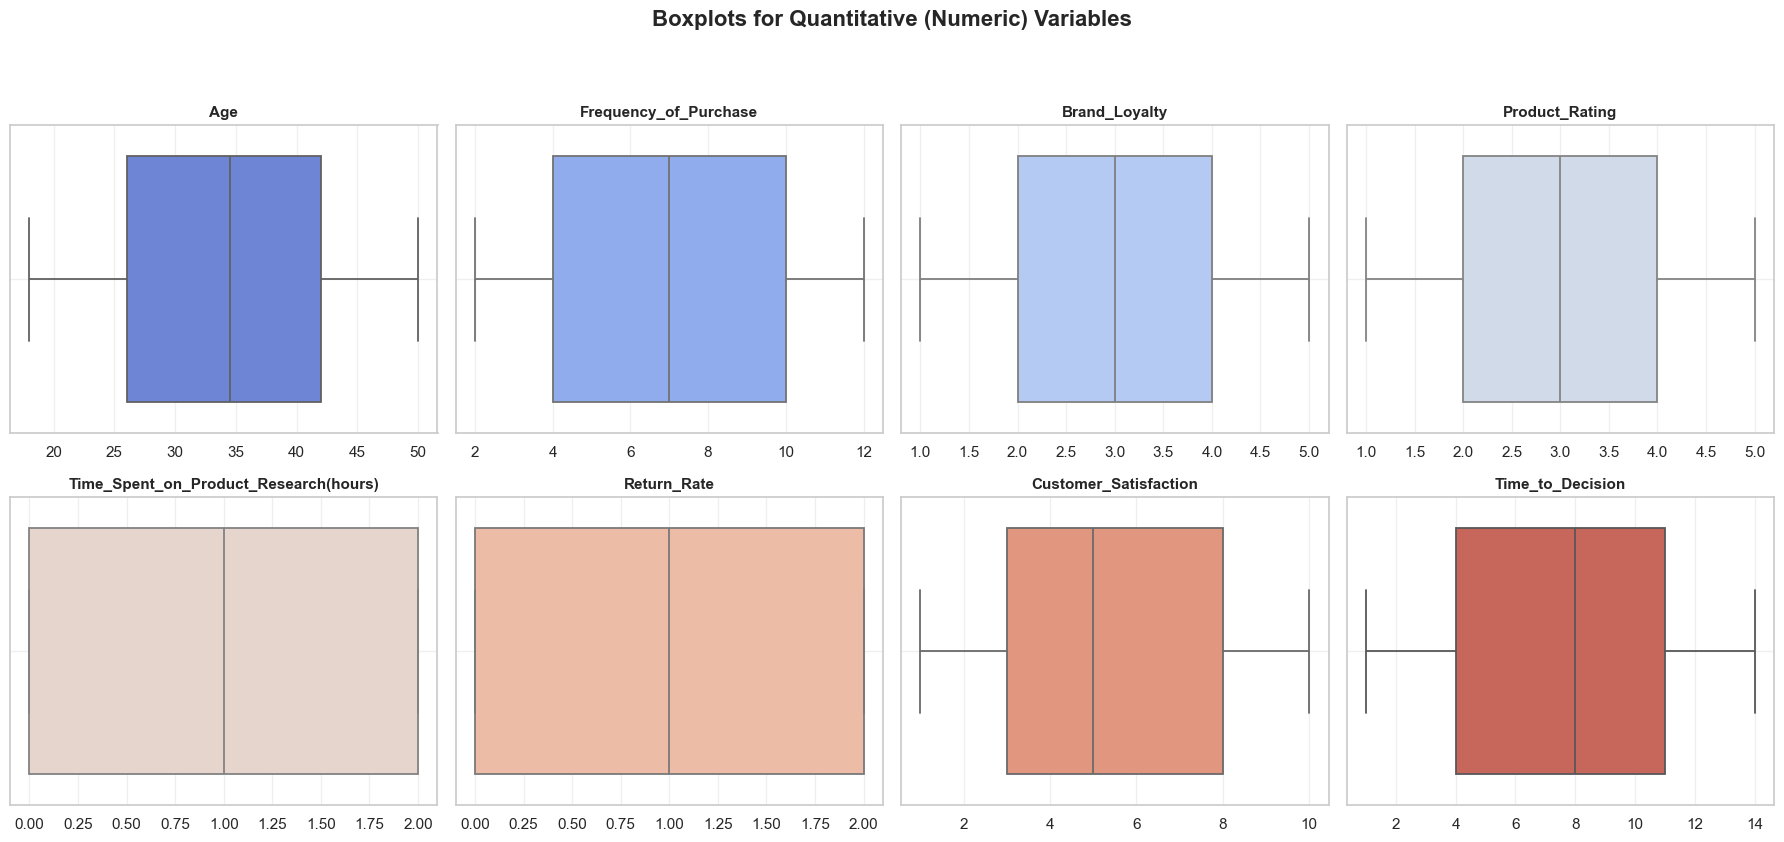

In [ ]:
# Lọc các cột định lượng (numeric)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns  # chỉ lấy 8 cột đầu tiên nếu nhiều hơn

print("Các cột định lượng được vẽ là:")
print(list(numeric_cols))

# Thiết lập style đẹp
sns.set(style="whitegrid", palette="pastel")

# Tạo figure 4x2 (8 biểu đồ nhỏ)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Duyệt qua từng cột và vẽ
for i, col in enumerate(numeric_cols):
    ax = axes[i // 4, i % 4]  # vị trí ô
    sns.boxplot(
        x=df[col],
        color=sns.color_palette("coolwarm", 8)[i],
        fliersize=3,
        linewidth=1.3,
        ax=ax
    )
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(alpha=0.3)

# Tiêu đề chung
plt.suptitle("Boxplots for Quantitative (Numeric) Variables", fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()


### Phân tích tần suất 

#### Tần suất theo giới tính

Tần suất theo giới tính:
Gender
Female         452
Male           449
Bigender        20
Agender         19
Genderfluid     17
Non-binary      16
Polygender      15
Genderqueer     12
Name: count, dtype: int64


/var/folders/qz/ss2rg5997d58bd_c8d2qpzxc0000gn/T/ipykernel_23198/300881084.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis")


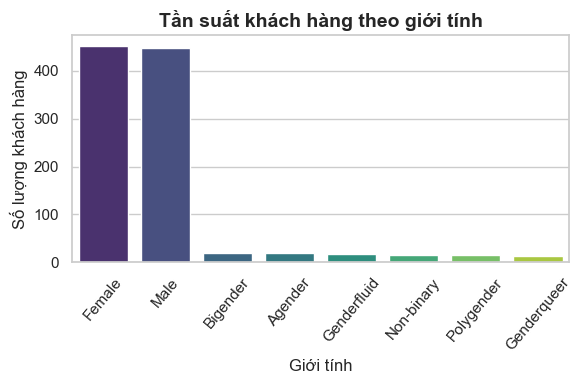

In [9]:
# Tần suất theo giới tính
gender_counts = df['Gender'].value_counts()

print("Tần suất theo giới tính:")
print(gender_counts)

# Vẽ biểu đồ
plt.figure(figsize=(6,4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="viridis")
plt.title("Tần suất khách hàng theo giới tính", fontsize=14, fontweight='bold')
plt.xlabel("Giới tính")
plt.xticks(rotation =50)
plt.ylabel("Số lượng khách hàng")
plt.tight_layout()
plt.show()



#### Tần suất mua hàng của khách hàng

/Library/anaconda3/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/anaconda3/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Library/anaconda3/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


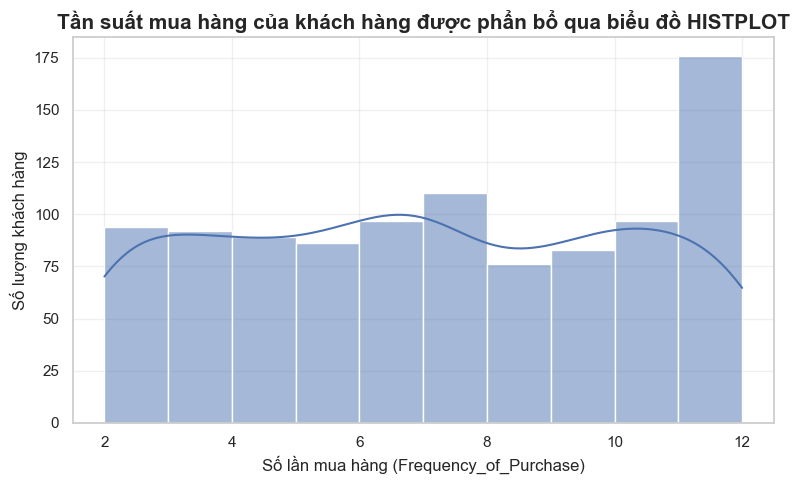

In [10]:
# Vẽ biểu đồ histogram phân bố tần suất mua hàng
plt.figure(figsize=(8,5))
sns.histplot(df["Frequency_of_Purchase"], bins=10, kde=True, color="#4C72B0")

plt.title("Tần suất mua hàng của khách hàng được phẩn bổ qua biểu đồ HISTPLOT", fontsize=15, fontweight='bold')
plt.xlabel("Số lần mua hàng (Frequency_of_Purchase)", fontsize=12)
plt.ylabel("Số lượng khách hàng", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Tần suất mua hàng theo tháng 

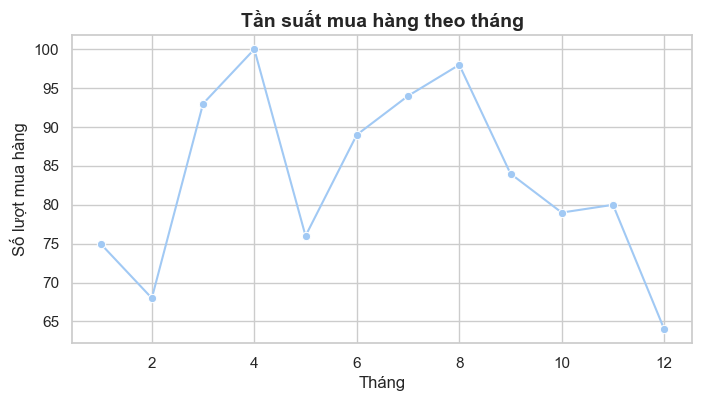

In [11]:
# Chuyển cột ngày
df["Time_of_Purchase"] = pd.to_datetime(df["Time_of_Purchase"], errors='coerce')

# Tính tần suất theo tháng
monthly_frequency = df["Time_of_Purchase"].dt.month.value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_frequency.index, y=monthly_frequency.values, marker="o")
plt.title("Tần suất mua hàng theo tháng", fontsize=14, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Số lượt mua hàng")
plt.show()


# Phân tích dự đoán 

## Phân cụm 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Frequency_of_Purchase  1000 non-null   int64  
 1   Purchase_Amount        1000 non-null   float64
 2   Income_Level           1000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None

Kích thước dữ liệu đã chuẩn hóa: (1000, 3)


/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/si

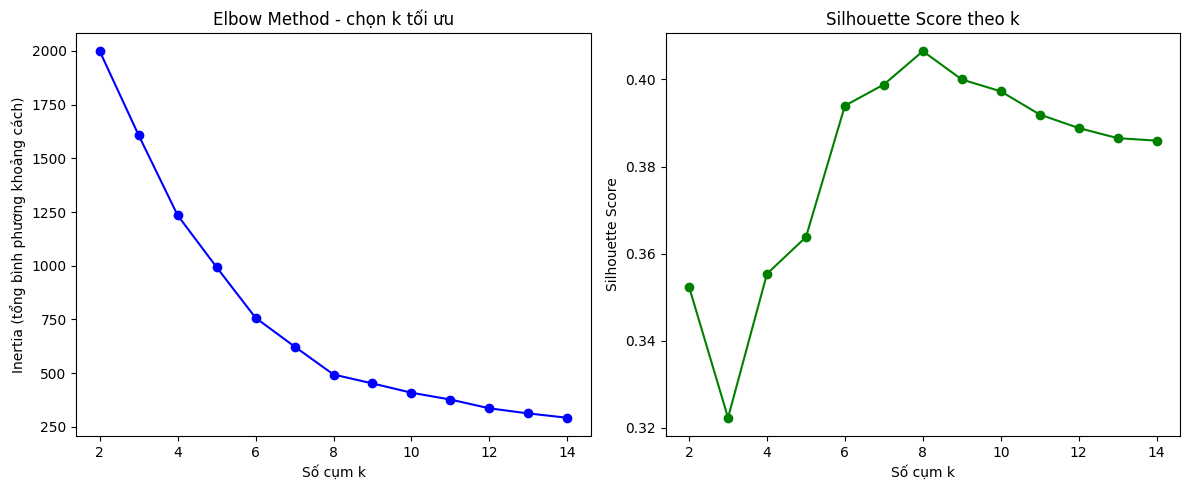

/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/si

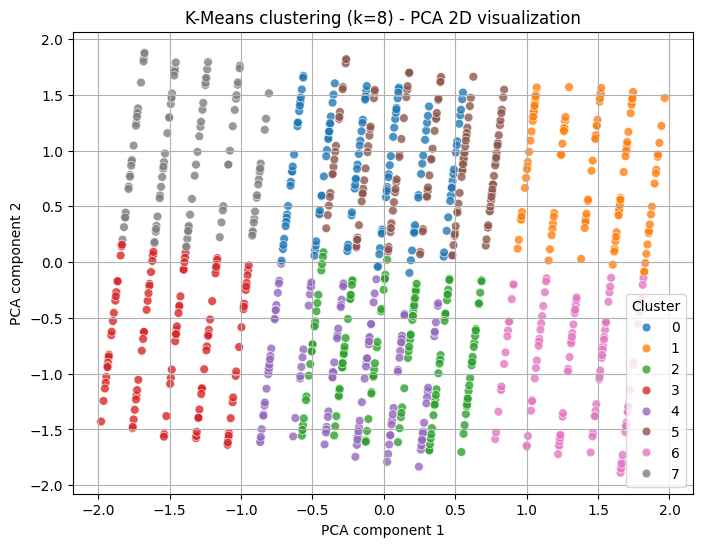


 Thống kê trung bình & độ lệch chuẩn theo từng cụm:
        Frequency_of_Purchase       Purchase_Amount        Income_Level     
                         mean   std            mean    std         mean  std
cluster                                                                     
0                        9.33  1.70          392.21  65.16          0.0  0.0
1                        9.96  1.41          399.83  63.22          1.0  0.0
2                        4.60  1.73          160.35  63.76          1.0  0.0
3                        3.96  1.44          165.07  69.46          0.0  0.0
4                        9.45  1.72          155.21  63.09          0.0  0.0
5                        4.80  1.71          383.45  61.97          1.0  0.0
6                       10.25  1.35          163.44  65.66          1.0  0.0
7                        3.76  1.41          382.80  68.95          0.0  0.0

CỤM 0: (133 khách hàng)
Frequency_of_Purchase      9.33
Purchase_Amount          392.21
Income_Leve

/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# 1) Tiền xử lý dữ liệu
#    - Làm sạch cột tiền tệ 'Purchase_Amount' (loại ký tự $, ,)
#    - Chuyển kiểu dữ liệu sang numeric để mô hình sử dụng được
if df["Purchase_Amount"].dtype =="object":
    df["Purchase_Amount"] = df["Purchase_Amount"].str.replace('[\$,]', '', regex=True)
    df["Purchase_Amount"] = pd.to_numeric(df["Purchase_Amount"])

# 2) Mã hoá biến phân loại
#    - One-Hot Encoding cho cột 'Income_Level'
#    - Lưu ý: encoder trả về mảng nhiều cột; ở đây ta gán lại vào 'Income_Level'
#      theo đúng ý đồ ban đầu (không thay đổi logic/kiến trúc code của bạn)
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)  # xuất mảng dense để dễ thao tác/quan sát
df["Income_Level"]= encoder.fit_transform(df[['Income_Level']])

# 3) Chọn các đặc trưng dùng cho mô hình phân cụm
#    - Tập trung vào: tần suất mua, số tiền mua, mức thu nhập (đã mã hoá)

cluster_features = [
    'Frequency_of_Purchase',
    'Purchase_Amount',             
    'Income_Level'
]
df_clustering = df[cluster_features].copy()


# 4) Xử lý dữ liệu khuyết
#    - Loại bỏ các dòng bị thiếu giá trị ở bất kỳ cột đặc trưng nào
df_clustering = df_clustering.dropna()
print(df_clustering.info())

# 5) Chuẩn hoá thang đo
#    - Dùng StandardScaler để đưa các đặc trưng về cùng thang đo (mean=0, std=1)
#    - Tránh đặc trưng có đơn vị lớn lấn át các đặc trưng khác
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)
print("\nKích thước dữ liệu đã chuẩn hóa:", X_scaled.shape)


# 6) Xác định số cụm phù hợp (k)
#    - Dùng kết hợp Elbow Method (Inertia/WCSS) và Silhouette Score
#    - Dò k trong khoảng [2..14] để tham khảo
inertia_list = []
silhouette_list = []
K = range(2, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))


# 7) Trực quan hoá các tiêu chí chọn k
#    - Biểu đồ Elbow: quan sát “điểm khuỷu”
#    - Biểu đồ Silhouette: chọn k có điểm số cao
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(K, inertia_list, 'o-', color='blue')
ax[0].set_title('Elbow Method - chọn k tối ưu')
ax[0].set_xlabel('Số cụm k')
ax[0].set_ylabel('Inertia (tổng bình phương khoảng cách)')

ax[1].plot(K, silhouette_list, 'o-', color='green')
ax[1].set_title('Silhouette Score theo k')
ax[1].set_xlabel('Số cụm k')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


# 8) Cố định k để huấn luyện mô hình cuối cùng
#    - Ở đây chọn k=8 theo kết quả quan sát từ biểu đồ (có thể điều chỉnh)
optimal_k = 8 # bạn có thể thay bằng giá trị thấy tối ưu từ biểu đồ
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)


# 9) Giảm chiều để trực quan hoá cụm
#    - PCA về 3 thành phần; hiển thị scatter 2D đầu tiên
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10', s=40, alpha=0.8)
plt.title(f"K-Means clustering (k={optimal_k}) - PCA 2D visualization")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True)
plt.legend(title='Cluster')
plt.show()


# 10) Thống kê mô tả theo cụm
#     - Trung bình và độ lệch chuẩn cho từng đặc trưng trong mỗi cụm
df_clustered = df_clustering.copy()
df_clustered['cluster'] = labels

cluster_summary = df_clustered.groupby('cluster').agg(['mean', 'std']).round(2)
print("\n Thống kê trung bình & độ lệch chuẩn theo từng cụm:")
print(cluster_summary)


# 11) In nhanh mô tả gợi ý từng cụm
#     - Số lượng phần tử và giá trị trung bình các đặc trưng nổi bật
for i in range(optimal_k):
    subset = df_clustered[df_clustered['cluster'] == i]
    print(f"\nCỤM {i}: ({len(subset)} khách hàng)")
    print(subset[cluster_features].mean().round(2))


# 12) Đánh giá chất lượng phân cụm
#     - Inertia (WCSS): Elbow method (thấp dần theo k)
#     - Silhouette Score: [−1, 1] càng cao càng tốt
#     - Davies-Bouldin Index: càng thấp càng tốt
inertia = kmeans.inertia_
silhouette = silhouette_score(X_scaled, kmeans.labels_)
db_index = davies_bouldin_score(X_scaled, kmeans.labels_)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {db_index:.3f}")


## Phát triển thêm
### Dùng DBSCAN để lọc outlier, thuật toán Birch và kết hợp thuật toán prophet để dự đoán doanh thu của cụm

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, Birch, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# 1) Lọc nhiễu trước khi so sánh (DBSCAN)
dbscan = DBSCAN(eps=1.5, min_samples=5)
noise_flag = dbscan.fit_predict(X_scaled)
mask_clean = noise_flag != -1
Xc = X_scaled[mask_clean]
Xc_df = df_clustering.loc[mask_clean].copy()
print(f"[INFO] Đã loại nhiễu: {np.sum(~mask_clean)} điểm / {len(mask_clean)} tổng số")

# 2) So sánh KMeans / GMM / Birch trên nhiều k
rows = []
K_range = range(2, 11)
for k in K_range:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc)
    km_labels = km.labels_
    rows.append(['KMeans', k,
                 silhouette_score(Xc, km_labels),
                 davies_bouldin_score(Xc, km_labels),
                 calinski_harabasz_score(Xc, km_labels),
                 np.nan])

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42).fit(Xc)
    gmm_labels = gmm.predict(Xc)
    gmm_conf = float(np.mean(np.max(gmm.predict_proba(Xc), axis=1)))
    rows.append(['GMM', k,
                 silhouette_score(Xc, gmm_labels),
                 davies_bouldin_score(Xc, gmm_labels),
                 calinski_harabasz_score(Xc, gmm_labels),
                 gmm_conf])

    # Birch
    bi = Birch(n_clusters=k).fit(Xc)
    bi_labels = bi.labels_
    rows.append(['Birch', k,
                 silhouette_score(Xc, bi_labels),
                 davies_bouldin_score(Xc, bi_labels),
                 calinski_harabasz_score(Xc, bi_labels),
                 np.nan])

compare_df = pd.DataFrame(rows, columns=[
    'Algorithm','k','Silhouette','DaviesBouldin','CalinskiHarabasz','Confidence'
]).sort_values(['Silhouette','DaviesBouldin'], ascending=[False, True]).reset_index(drop=True)

print("\n=== BẢNG SO SÁNH (TOP 12) ===")
print(compare_df.head(12))

# 3) Chọn mô hình tối ưu: Silhouette ↑ → DBI ↓ (tie-break: GMM có Confidence ↑)
best = compare_df.iloc[0].to_dict()
if len(compare_df) > 1:
    t0 = compare_df.iloc[0]; t1 = compare_df.iloc[1]
    if (t0['Silhouette']==t1['Silhouette']) and (t0['DaviesBouldin']==t1['DaviesBouldin']):
        tied = compare_df.iloc[:5]
        gmm_tied = tied[tied['Algorithm']=='GMM']
        if len(gmm_tied):
            best = gmm_tied.sort_values('Confidence', ascending=False).iloc[0].to_dict()

algo, k_opt = best['Algorithm'], int(best['k'])
print(f"\n[CHỌN] {algo} (k={k_opt}) | Sil={best['Silhouette']:.3f} | DBI={best['DaviesBouldin']:.3f} | CH={best['CalinskiHarabasz']:.0f}"
      + (f" | Conf={best['Confidence']:.3f}" if pd.notna(best['Confidence']) else ""))

# 4) Fit lại mô hình chọn cuối để lấy nhãn cụm
if algo=='KMeans':
    final_model = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(Xc)
    final_labels = final_model.labels_
elif algo=='GMM':
    final_model = GaussianMixture(n_components=k_opt, random_state=42).fit(Xc)
    final_labels = final_model.predict(Xc)
else:
    final_model = Birch(n_clusters=k_opt).fit(Xc)
    final_labels = final_model.labels_

sil = silhouette_score(Xc, final_labels)
dbi = davies_bouldin_score(Xc, final_labels)
ch  = calinski_harabasz_score(Xc, final_labels)
print("\n=== ĐÁNH GIÁ MÔ HÌNH CHỌN CUỐI ===")
print(f"- Silhouette       : {sil:.3f} (càng gần 1 càng tốt)")
print(f"- Davies-Bouldin  : {dbi:.3f} (càng thấp càng tốt)")
print(f"- Calinski-Harabasz: {ch:.0f} (càng cao càng tốt)")


[INFO] Đã loại nhiễu: 0 điểm / 1000 tổng số


/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/anaconda3/lib/python3.11/si


=== BẢNG SO SÁNH (TOP 12) ===
   Algorithm   k  Silhouette  DaviesBouldin  CalinskiHarabasz  Confidence
0     KMeans   8    0.406484       0.777192        719.321924         NaN
1     KMeans   9    0.399986       0.830219        697.578764         NaN
2     KMeans   7    0.398831       0.804719        629.998428         NaN
3     KMeans  10    0.397271       0.837861        696.538943         NaN
4     KMeans   6    0.393974       0.828218        588.263805         NaN
5        GMM   7    0.385216       0.819839        597.480509    0.887173
6        GMM   9    0.381915       0.850792        676.393875    0.859658
7        GMM  10    0.377125       0.879049        660.113992    0.868382
8        GMM   8    0.369769       0.889883        558.374797    0.878365
9     KMeans   5    0.363804       0.969183        502.629442         NaN
10     Birch   8    0.358886       0.784256        593.322572         NaN
11     Birch   9    0.358144       0.826675        592.306964         NaN

[CHỌN]

/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_p

/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


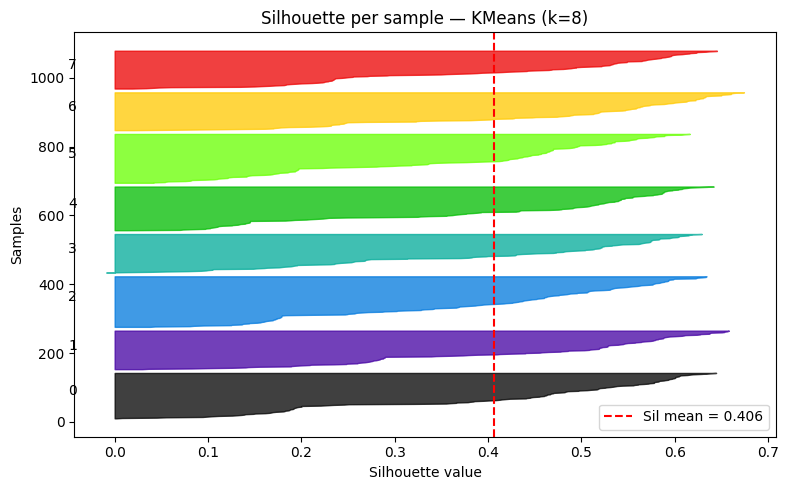

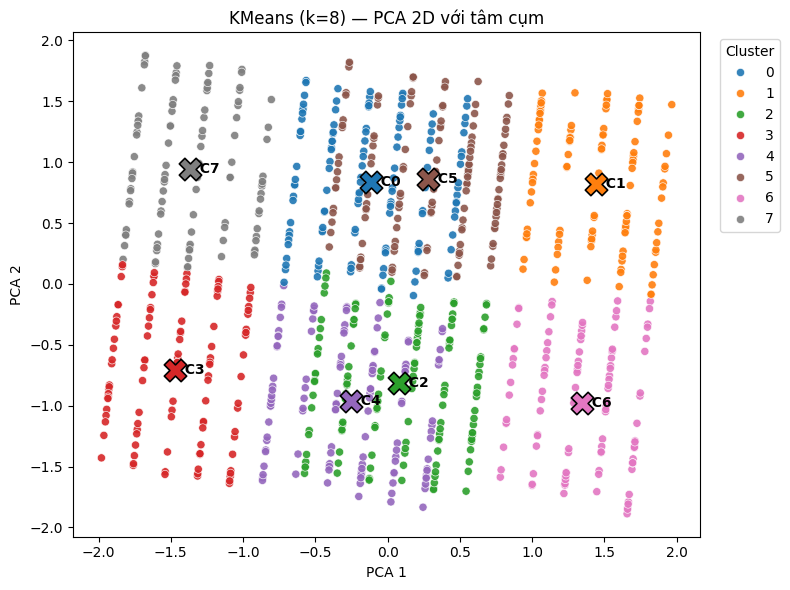

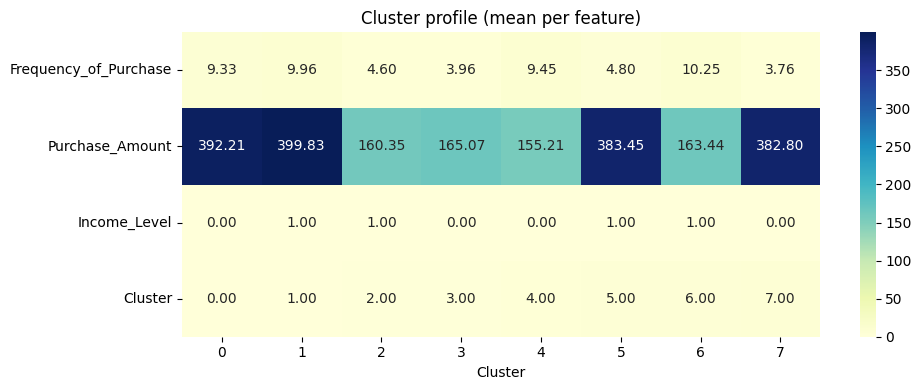

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

# 1) Silhouette per-sample
fig, ax = plt.subplots(1, 1, figsize=(8,5))
sil_vals = silhouette_samples(Xc, final_labels)
y_lower = 10
for c in np.unique(final_labels):
    s = sil_vals[final_labels==c]; s.sort()
    y_upper = y_lower + len(s)
    color = cm.nipy_spectral(float(c) / (final_labels.max()+1))
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, s, facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5*len(s), str(c))
    y_lower = y_upper + 10
ax.axvline(np.mean(sil_vals), color='red', ls='--', label=f"Sil mean = {np.mean(sil_vals):.3f}")
ax.set_title(f"Silhouette per sample — {algo} (k={k_opt})")
ax.set_xlabel("Silhouette value"); ax.set_ylabel("Samples"); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# 2) PCA 2D + tâm cụm
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xc)

plt.figure(figsize=(8,6))
palette = sns.color_palette("tab10", n_colors=len(np.unique(final_labels)))
sns.scatterplot(x=Xp[:,0], y=Xp[:,1], hue=final_labels, palette=palette, s=35, alpha=0.9)
for c in np.unique(final_labels):
    mu = Xp[final_labels==c].mean(axis=0)
    plt.scatter(mu[0], mu[1], s=260, marker='X', color=palette[c], edgecolor='black', linewidth=1.2)
    plt.text(mu[0], mu[1], f"  C{c}", va='center', weight='bold')
plt.title(f"{algo} (k={k_opt}) — PCA 2D với tâm cụm")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout(); plt.show()

# 3) Heatmap hồ sơ cụm (trung bình theo feature)
seg_df = Xc_df.copy(); seg_df['Cluster'] = final_labels
prof = seg_df.groupby('Cluster')[seg_df.columns].mean().T
plt.figure(figsize=(10, max(4, 0.4*prof.shape[0])))
sns.heatmap(prof, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cluster profile (mean per feature)")
plt.tight_layout(); plt.show()


Importing plotly failed. Interactive plots will not work.


Đã loại outliers: 281 / 1000 khách hàng
Số cụm tối ưu (theo GMM+Silhouette): K = 2


/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b

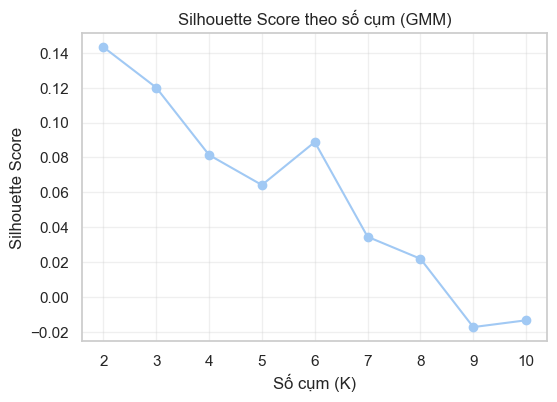

/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b


=== ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM ===
- Số cụm tối ưu: 2
- Silhouette Score: 0.138 (→ càng gần 1, phân tách càng tốt)
- Davies-Bouldin Score: 2.486 (→ càng nhỏ, cụm càng rõ)
- Inertia (WCSS | Elbow tham chiếu): 4,457.63

=== ĐẶC TRƯNG TRUNG BÌNH THEO CỤM ===
         Recency  Frequency  Monetary    Age  Brand_Loyalty  \
Cluster                                                       
0         182.04       6.81    273.67  33.55           3.08   
1         190.66       6.75    279.96  34.31           3.20   

         Customer_Satisfaction  Gender  Income_Level  Customer_Count  
Cluster                                                               
0                         5.31    3.43          0.98             389  
1                         5.74    3.60          0.00             330  

=== DIỄN GIẢI Ý NGHĨA & KHUYẾN NGHỊ THEO CỤM ===

Cụm 0: Potential / Growing (tiềm năng phát triển)
- Khách hàng: 389
- Recency/Frequency/Monetary trung bình: 182.04/6.81/273.67
- Brand Loyalty / Satisfacti

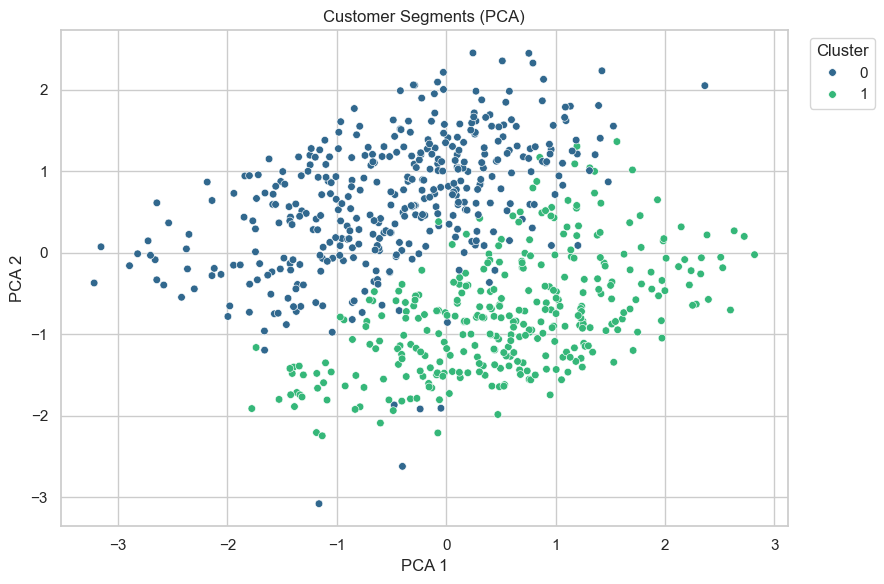

15:24:40 - cmdstanpy - INFO - Chain [1] start processing



=== DỰ BÁO DOANH THU THEO CỤM (PROPHET) ===


15:24:41 - cmdstanpy - INFO - Chain [1] done processing



Dự báo cho Cluster 0:
            ds    yhat
251 2024-12-31  357.87
252 2025-01-31  455.80
253 2025-02-28  453.18
254 2025-03-31  476.36
255 2025-04-30  433.74
256 2025-05-31  388.09
257 2025-06-30  611.03
258 2025-07-31  461.21
259 2025-08-31  314.40
260 2025-09-30  394.16
261 2025-10-31  329.58
262 2025-11-30  327.54


/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matm

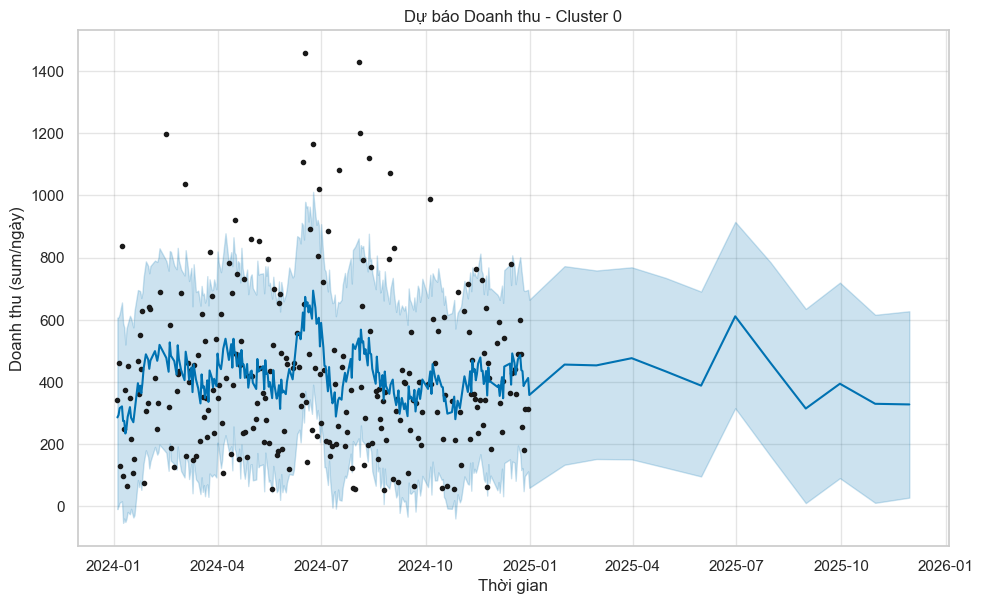

/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())


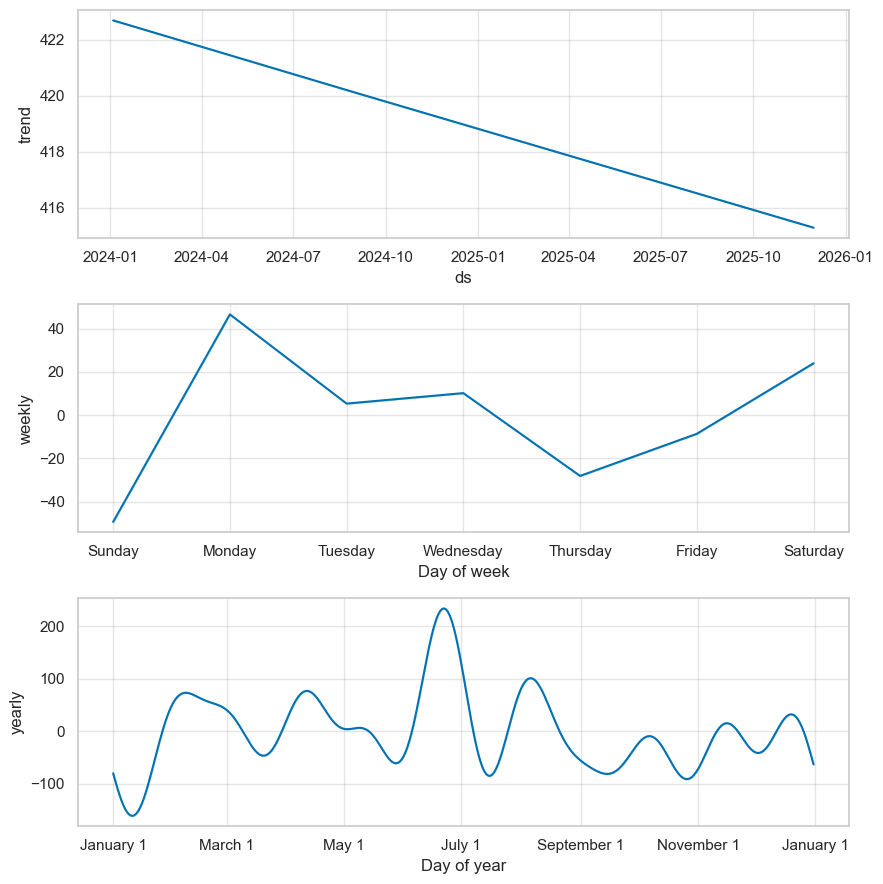

15:24:41 - cmdstanpy - INFO - Chain [1] start processing
15:24:41 - cmdstanpy - INFO - Chain [1] done processing


Đánh giá Prophet (Cluster 0):
- MAE : 187.09
- RMSE: 244.74
- R²  : 0.099
- MAPE: 76.58%


/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matm


Dự báo cho Cluster 1:
            ds    yhat
211 2024-12-31  127.58
212 2025-01-31  190.48
213 2025-02-28  276.91
214 2025-03-31  399.15
215 2025-04-30  429.61
216 2025-05-31  419.00
217 2025-06-30  293.77
218 2025-07-31  393.97
219 2025-08-31  618.62
220 2025-09-30  210.84
221 2025-10-31  238.59
222 2025-11-30  408.76


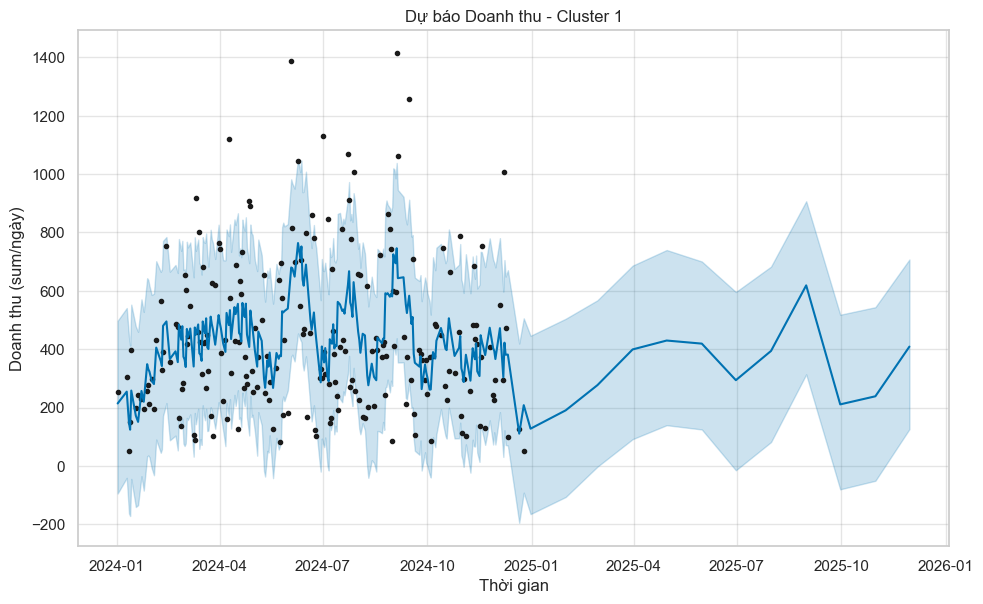

/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())


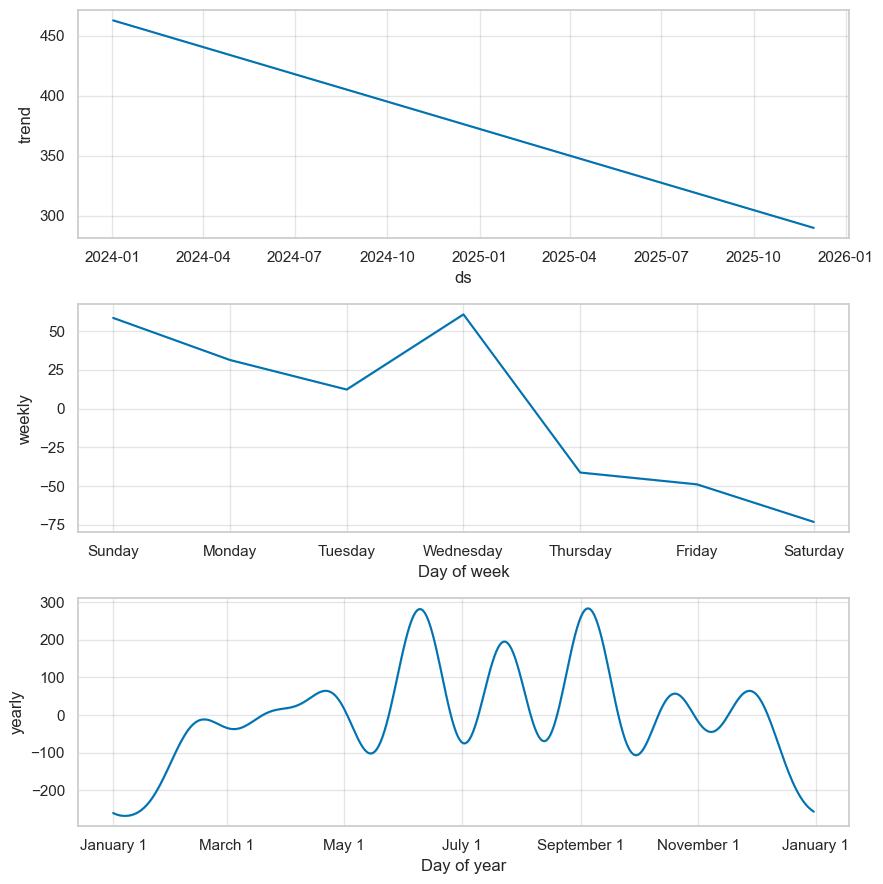

Đánh giá Prophet (Cluster 1):
- MAE : 181.19
- RMSE: 234.14
- R²  : 0.211
- MAPE: 63.95%


In [15]:
# 1) IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN, Birch, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.decomposition import PCA

# Prophet có thể không cài trên một số môi trường, thêm try/except cho an toàn
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    PROPHET_AVAILABLE = False
    print("Prophet chưa sẵn sàng, bỏ qua phần dự báo. Lỗi:", e)

# 2) LOAD DATA
if 'df' not in globals():
    df = pd.read_csv('Ecommerce_Consumer_Behavior_Analysis_Data.csv')

# Chuẩn hóa tên cột (nếu có khoảng trắng/khác biệt)
df.columns = [c.strip() for c in df.columns]

# 3) FEATURE ENGINEERING RFM + THUỘC TÍNH
# Bảo đảm cột cần thiết tồn tại
required_cols = [
    'Customer_ID', 'Time_of_Purchase', 'Frequency_of_Purchase',
    'Purchase_Amount', 'Age', 'Gender', 'Income_Level',
    'Brand_Loyalty', 'Customer_Satisfaction'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Thiếu cột bắt buộc: {missing}")

# Chuẩn hóa thời gian & tiền
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], errors='coerce')

# Nếu Purchase_Amount là string có ký tự $, , khoảng trắng → làm sạch
def _to_float_money(series):
    if pd.api.types.is_string_dtype(series):
        return series.str.replace(r'[\$, ]', '', regex=True).astype(float)
    return series.astype(float)

money_float = _to_float_money(df['Purchase_Amount'])
current_date = df['Time_of_Purchase'].max() + pd.Timedelta(days=1)

# Tính RFM theo Customer_ID
rfm = df.groupby('Customer_ID').agg({
    'Time_of_Purchase': lambda x: (current_date - x.max()).days,  # Recency (days)
    'Frequency_of_Purchase': 'sum',                               # Frequency
}).rename(columns={'Time_of_Purchase': 'Recency',
                   'Frequency_of_Purchase': 'Frequency'})

# Monetary cần cộng sau vì ta đã làm sạch riêng
monetary_sum = (
    df.assign(Purchase_Amount_Clean=money_float)
      .groupby('Customer_ID')['Purchase_Amount_Clean']
      .sum()
)
rfm['Monetary'] = monetary_sum

# Các thuộc tính nhân khẩu học/hài lòng/trung thành
features = ['Age', 'Gender', 'Income_Level', 'Brand_Loyalty', 'Customer_Satisfaction']
df_features = (
    df[['Customer_ID'] + features]
    .drop_duplicates('Customer_ID')
    .set_index('Customer_ID')
)

# Merge
df_prep = rfm.join(df_features, how='left')

# 4) XỬ LÝ THIẾU + ENCODE
num_cols = ['Recency', 'Frequency', 'Monetary', 'Age', 'Brand_Loyalty', 'Customer_Satisfaction']
cat_cols = ['Gender', 'Income_Level']

for col in num_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mean())
for col in cat_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

# Encode categorical
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    le_dict[col] = le

# 5) SCALE
scaler = StandardScaler()
X = df_prep[num_cols + cat_cols].values
X_scaled = scaler.fit_transform(X)

# 6) OUTLIER DETECTION (DBSCAN) & LỌC
dbscan = DBSCAN(eps=1.5, min_samples=5)
outlier_labels = dbscan.fit_predict(X_scaled)
df_prep['Outlier'] = outlier_labels

df_clean = df_prep[df_prep['Outlier'] != -1].copy()
X_clean_scaled = X_scaled[df_prep['Outlier'] != -1]

print(f"Đã loại outliers: {np.sum(outlier_labels == -1)} / {len(outlier_labels)} khách hàng")

# 7) CHỌN SỐ CỤM TỐI ƯU (GMM + SILHOUETTE)
range_k = range(2, 11)
sil_scores = []
for n in range_k:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm_labels = gmm.fit_predict(X_clean_scaled)
    sil = silhouette_score(X_clean_scaled, gmm_labels)
    sil_scores.append(sil)

optimal_n = int(list(range_k)[np.argmax(sil_scores)])
print(f"Số cụm tối ưu (theo GMM+Silhouette): K = {optimal_n}")

# Vẽ biểu đồ Silhouette theo K
plt.figure(figsize=(6, 4))
plt.plot(list(range_k), sil_scores, marker='o')
plt.title('Silhouette Score theo số cụm (GMM)')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.show()

# 8) PHÂN CỤM CHÍNH THỨC (BIRCH)
birch = Birch(n_clusters=optimal_n)
cluster_labels = birch.fit_predict(X_clean_scaled)
df_clean['Cluster'] = cluster_labels

# 9) ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM
sil = silhouette_score(X_clean_scaled, cluster_labels)
db = davies_bouldin_score(X_clean_scaled, cluster_labels)
# Inertia/Elbow (dùng KMeans để tham chiếu WCSS)
kmeans_ref = KMeans(n_clusters=optimal_n, random_state=42, n_init='auto').fit(X_clean_scaled)
inertia = kmeans_ref.inertia_

print("\n=== ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM ===")
print(f"- Số cụm tối ưu: {optimal_n}")
print(f"- Silhouette Score: {sil:.3f} (→ càng gần 1, phân tách càng tốt)")
print(f"- Davies-Bouldin Score: {db:.3f} (→ càng nhỏ, cụm càng rõ)")
print(f"- Inertia (WCSS | Elbow tham chiếu): {inertia:,.2f}")

# 10) TÓM TẮT THỐNG KÊ CỤM
summary_cols = [
    'Recency', 'Frequency', 'Monetary', 'Age',
    'Brand_Loyalty', 'Customer_Satisfaction', 'Gender', 'Income_Level'
]
cluster_summary = df_clean.groupby('Cluster')[summary_cols].mean().round(2)
cluster_counts = df_clean['Cluster'].value_counts().sort_index()
cluster_summary['Customer_Count'] = cluster_counts
print("\n=== ĐẶC TRƯNG TRUNG BÌNH THEO CỤM ===")
print(cluster_summary)

# Phân bố giới tính & thu nhập (giải thích dễ hiểu): lấy mode (phổ biến nhất)
def mode_decoded(series, le):
    # series là giá trị đã encode, lấy mode rồi inverse để ra nhãn gốc
    m = pd.Series(series).mode()
    if len(m) == 0:
        return None
    try:
        return le.inverse_transform([int(m.iloc[0])])[0]
    except Exception:
        return str(m.iloc[0])

cluster_mode_gender = df_clean.groupby('Cluster')['Gender'].apply(
    lambda s: mode_decoded(s, le_dict['Gender'])
)
cluster_mode_income = df_clean.groupby('Cluster')['Income_Level'].apply(
    lambda s: mode_decoded(s, le_dict['Income_Level'])
)

# 11) DIỄN GIẢI Ý NGHĨA CỤM (TỰ ĐỘNG)
# Tạo thang điểm giá trị (Value Score): Recency (đảo dấu), Frequency, Monetary, Loyalty, Satisfaction
z = lambda v: (v - v.mean()) / (v.std(ddof=0) + 1e-9)
val_df = pd.DataFrame({
    'Cluster': df_clean['Cluster'],
    'v_recency': z(-df_clean['Recency']),  # recency càng thấp càng tốt → đảo dấu
    'v_freq': z(df_clean['Frequency']),
    'v_mon': z(df_clean['Monetary']),
    'v_loy': z(df_clean['Brand_Loyalty']),
    'v_sat': z(df_clean['Customer_Satisfaction'])
})
val_df['value_score'] = val_df[['v_recency','v_freq','v_mon','v_loy','v_sat']].mean(axis=1)
value_by_cluster = val_df.groupby('Cluster')['value_score'].mean().sort_values(ascending=False)

ranked_clusters = list(value_by_cluster.index)  # cluster theo giá trị giảm dần
interpretation = {}
for i, c in enumerate(ranked_clusters):
    if i == 0:
        tag = "VIP / High-Value (giá trị cao nhất)"
        rec = [
            "Chương trình VIP/tích điểm, ưu đãi cá nhân hóa",
            "CSKH chủ động (call/email định kỳ), early-access sản phẩm",
            "Giữ chân: voucher sinh nhật, combo gia tăng giá trị"
        ]
    elif i == 1:
        tag = "Potential / Growing (tiềm năng phát triển)"
        rec = [
            "Remarketing theo chu kỳ mua, gợi ý sản phẩm bổ sung",
            "Bundle/upsell nhẹ, miễn phí vận chuyển threshold",
            "Nuôi dưỡng bằng nội dung: review, HDSD, case thực tế"
        ]
    else:
        tag = "At-Risk / Churn-Prone (nguy cơ rời bỏ)"
        rec = [
            "Re-engagement: mã giảm giá quay lại, email kích hoạt",
            "Khảo sát rào cản (giá, shipping, trải nghiệm)",
            "Giảm ma sát checkout, tối ưu fee/đổi trả"
        ]
    interpretation[c] = {'segment': tag, 'recommendations': rec}

print("\n=== DIỄN GIẢI Ý NGHĨA & KHUYẾN NGHỊ THEO CỤM ===")
for c in sorted(df_clean['Cluster'].unique()):
    print(f"\nCụm {c}: {interpretation[c]['segment']}")
    print(f"- Khách hàng: {int(cluster_counts.loc[c])}")
    print(f"- Recency/Frequency/Monetary trung bình: "
          f"{cluster_summary.loc[c,'Recency']}/{cluster_summary.loc[c,'Frequency']}/{cluster_summary.loc[c,'Monetary']}")
    print(f"- Brand Loyalty / Satisfaction TB: "
          f"{cluster_summary.loc[c,'Brand_Loyalty']} / {cluster_summary.loc[c,'Customer_Satisfaction']}")
    print(f"- Giới tính phổ biến: {cluster_mode_gender.loc[c]} | Nhóm thu nhập phổ biến: {cluster_mode_income.loc[c]}")
    print("- Khuyến nghị:")
    for r in interpretation[c]['recommendations']:
        print(f"   • {r}")

# 12) PCA TRỰC QUAN
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clean_scaled)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['Cluster'], palette='viridis', s=30)
plt.title('Customer Segments (PCA)')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 13) DỰ BÁO DOANH THU THEO CỤM (PROPHET) + ĐÁNH GIÁ
if PROPHET_AVAILABLE:
    print("\n=== DỰ BÁO DOANH THU THEO CỤM (PROPHET) ===")
    # Chuẩn bị dữ liệu gốc theo từng đơn hàng
    df_money = df.copy()
    df_money['Time_of_Purchase'] = pd.to_datetime(df_money['Time_of_Purchase'], errors='coerce')
    df_money['Purchase_Amount_Clean'] = money_float

    for cluster in sorted(df_clean['Cluster'].unique()):
        # Tập khách hàng thuộc cụm này
        cust_ids = df_clean.index[df_clean['Cluster'] == cluster]
        df_cluster = df_money[df_money['Customer_ID'].isin(cust_ids)]

        # Chuẩn bị data Prophet
        df_prophet = (
            df_cluster[['Time_of_Purchase', 'Purchase_Amount_Clean']]
            .rename(columns={'Time_of_Purchase': 'ds', 'Purchase_Amount_Clean': 'y'})
            .dropna()
        )
        # Gộp theo ngày
        df_prophet = df_prophet.groupby('ds', as_index=False)['y'].sum().sort_values('ds')

        # Bỏ qua nếu quá ít điểm (Prophet cần chuỗi đủ dài)
        if len(df_prophet) < 20 or df_prophet['y'].sum() == 0:
            print(f"Cluster {cluster}: Dữ liệu không đủ để dự báo (n={len(df_prophet)}).")
            continue

        # Fit
        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(df_prophet)

        # Tạo tương lai 12 tháng (freq='M' → cuối tháng)
        future = model.make_future_dataframe(periods=12, freq='M')
        forecast = model.predict(future)

        # Đánh giá in-sample (ghép yhat vào ds trùng)
        df_eval = df_prophet.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
        y_true = df_eval['y'].values
        y_pred = df_eval['yhat'].values
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-9))) * 100)

        print(f"\nDự báo cho Cluster {cluster}:")
        print(forecast[['ds', 'yhat']].tail(12).round(2))

        # Plot dự báo
        fig1 = model.plot(forecast)
        plt.title(f'Dự báo Doanh thu - Cluster {cluster}')
        plt.xlabel('Thời gian'); plt.ylabel('Doanh thu (sum/ngày)')
        plt.show()

        # Plot components (xu hướng/seasonality)
        fig2 = model.plot_components(forecast)
        plt.show()

        print(f"Đánh giá Prophet (Cluster {cluster}):")
        print(f"- MAE : {mae:,.2f}")
        print(f"- RMSE: {rmse:,.2f}")
        print(f"- R²  : {r2:.3f}")
        print(f"- MAPE: {mape:.2f}%")
else:
    print("\n Bỏ qua phần Prophet do chưa sẵn sàng trong môi trường hiện tại.")


### dùng DBSCAN để lọc outlier

Phân cụm rất nhạy với ngoại lệ. Doanh thu có thể có đơn hàng dị thường (flash sale, lỗi import).

DBSCAN phát hiện điểm nhiễu/ cô độc dựa trên mật độ mà không cần biết số cụm trước.
Ưu điểm:

Không “kéo” centroid/ boundary như K-Means.

Loại outlier trước khi chọn K giúp Silhouette/DBI/CH đáng tin hơn.

Trong bối cảnh bán lẻ, vài giao dịch “đột biến” là phổ biến → lọc trước để cụm ổn định và giải thích dễ.

### Dùng GMM + Silhouette để chọn số cụm K

GMM (Gaussian Mixture) xem dữ liệu là trộn nhiều phân phối → xác suất thuộc cụm mềm mại hơn so với biên cứng của K-Means.

Dùng GMM để “thăm dò” cấu trúc, tính Silhouette cho từng k=2..10 → chọn K tối ưu theo độ tách cụm (Silhouette ↑ tốt).

Lý do không chọn “Elbow” thuần túy: Elbow dựa vào WCSS (phù hợp K-Means và giả định “cầu phương”), còn RFM + nhân khẩu học thường không hoàn toàn cầu phương.

### Phân cụm chính thức bằng Birch (sau khi biết K)

Birch tạo micro-clusters theo cây CF, rất nhanh & tiết kiệm bộ nhớ khi số khách/điểm lớn—hợp bối cảnh doanh nghiệp.

Thực tế, Birch ổn định với phân phối không quá cầu phương và hoạt động tốt sau khi đã lọc outlier.

So với K-Means:

K-Means giả định cụm hình cầu, nhạy outlier, khó mở rộng online.

Birch xử lý incremental tốt hơn, phù hợp cập nhật dữ liệu theo thời gian.

So với GMM:

GMM mạnh về mô hình xác suất nhưng tốn chi phí và có thể “quá mềm”; Birch là lựa chọn cân bằng giữa chất lượng & hiệu năng.

Bạn vẫn có KMeans_ref để tham chiếu Inertia (WCSS)—giúp “ăn nói” với người quen Elbow method.

## Cluster 0 – Nhóm khách hàng có nguy cơ rời bỏ (At-Risk Segment)

### Đặc điểm hành vi:

Tần suất mua hàng thấp và không ổn định.

Giá trị chi tiêu biến động mạnh giữa các lần mua.

Recency cao, khách hàng lâu quay lại mua.

Mức độ trung thành và hài lòng ở mức trung bình, có xu hướng giảm dần.

Dễ rời bỏ thương hiệu nếu không được nhắc nhở hoặc khuyến khích.

### Kết quả đánh giá dự báo:

MAE = 187.09 → Sai số trung bình tương đối lớn.

RMSE = 244.74 → Mức độ dao động sai số cao.

R² = 0.099 → Mô hình gần như không giải thích được biến động doanh thu.

MAPE = 76.58% → Sai số dự báo lớn, hành vi mua rất khó đoán.

### Ý nghĩa kinh doanh:

Nhóm khách hàng này đang có xu hướng giảm tương tác và rời bỏ thương hiệu.

Không phù hợp để tập trung tăng doanh thu, mà ưu tiên giữ chân và tái kích hoạt mua hàng.

### Chiến lược đề xuất:

Gửi voucher quay lại hoặc mã giảm giá giới hạn thời gian.

Triển khai chiến dịch remarketing nhắc nhớ giỏ hàng.

Gửi email chăm sóc / khảo sát hài lòng để xác định nguyên nhân rời bỏ.

Tạo gói combo nhỏ + miễn phí vận chuyển nhằm giảm rào cản mua.

Ưu tiên duy trì liên hệ nhẹ nhàng → không đẩy quảng cáo mạnh gây phản tác dụng.

## Cluster 1 – Nhóm khách hàng tiềm năng (Potential / Growth Segment)

### Đặc điểm hành vi:

Tần suất mua ổn định và có xu hướng tăng dần.

Tổng chi tiêu ở mức trung bình, nhưng có khả năng tăng trưởng.

Mức độ trung thành và hài lòng khá tốt.

Recency không quá cao → khách hàng vẫn đang giữ thói quen mua hàng.

### Kết quả đánh giá dự báo:

MAE = 181.19 → Sai số thấp hơn cụm 0.

RMSE = 234.14 → Sai số vừa phải, phù hợp phân tích xu hướng.

R² = 0.211 → Mô hình đã nắm được một phần xu hướng tăng giảm doanh thu.

MAPE = 63.95% → Sai số còn cao nhưng xu hướng dự báo có giá trị tham khảo.

### Ý nghĩa kinh doanh:

Đây là nhóm khách hàng quan trọng để đầu tư phát triển dài hạn.

Có thể chuyển đổi thành nhóm khách hàng trung thành (VIP) nếu có chiến lược phù hợp.

Mang lại doanh thu tăng trưởng ổn định theo thời gian.

### Chiến lược đề xuất:

Gửi gợi ý sản phẩm cá nhân hóa dựa trên lịch sử mua.

Tạo chương trình tích điểm, xếp hạng thành viên để tăng gắn kết.

Đẩy cross-sell / upsell ở các sản phẩm có liên quan.

Tặng ưu đãi sinh nhật, ưu tiên flash sale cho nhóm khách hàng này.

Chăm sóc nội dung: review sản phẩm, hướng dẫn sử dụng, feedback social.

### Dự đoán doanh thu 

    Time_of_Purchase  Purchase_Amount  Frequency_of_Purchase  Product_Rating  \
0         2024-03-01           333.80                      4               5   
1         2024-04-16           222.22                     11               1   
2         2024-03-15           426.22                      2               5   
3         2024-10-04           101.31                      6               1   
4         2024-01-30           211.70                      6               4   
..               ...              ...                    ...             ...   
995       2024-07-07           463.67                      5               4   
996       2024-03-28            69.78                      9               3   
997       2024-03-11           453.37                     10               1   
998       2024-03-30           106.15                     12               4   
999       2024-12-08           378.47                      6               2   

     Time_Spent_on_Product_Research(hou

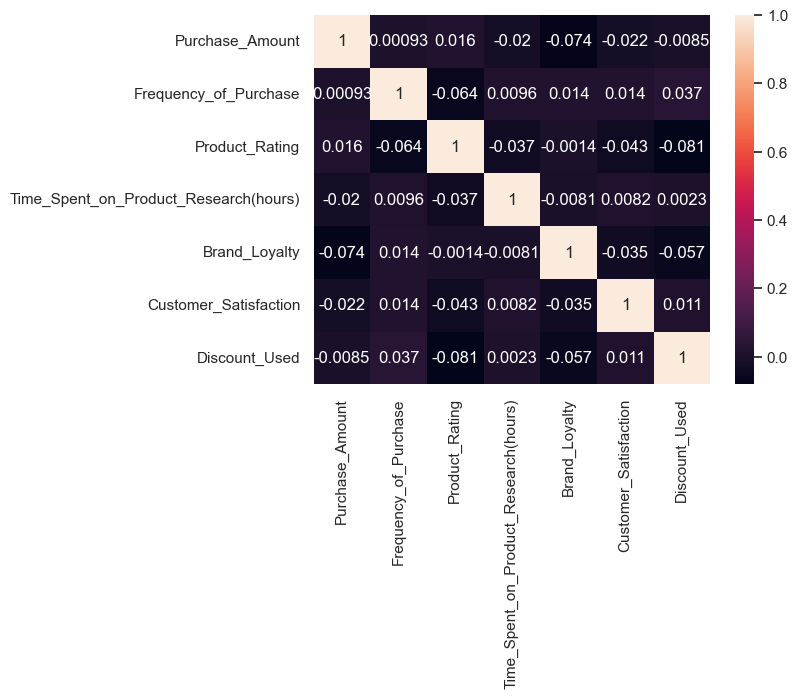

In [16]:
features_prophet = [
    "Time_of_Purchase",
    "Purchase_Amount",
    "Frequency_of_Purchase",
    "Product_Rating",
    "Time_Spent_on_Product_Research(hours)",
    "Brand_Loyalty",
    "Customer_Satisfaction",
    "Discount_Used"
]
df_prophet = df[features_prophet].copy()

if df['Discount_Used'].dtype == 'object':
    df['Discount_Used'] = le.fit_transform(df['Discount_Used'])

df_corr = df_prophet.drop(columns= "Time_of_Purchase", axis =1 )
print(df_prophet)

sns.heatmap(df_corr.corr(),annot= True)
print(df_corr)
print(df_prophet.info())


In [18]:
df_prophet_main = df_prophet[[
    "Time_of_Purchase",
    "Purchase_Amount",
    "Frequency_of_Purchase",
    "Product_Rating",
    ]].reset_index()
df_prophet_main = df_prophet_main.dropna()

if df_prophet_main['Purchase_Amount'].dtype == 'object':
    df_prophet_main["Purchase_Amount"] = df_prophet_main["Purchase_Amount"].str.replace('[\$,]', '', regex=True)
    df_prophet_main["Purchase_Amount"] = pd.to_numeric(df_prophet_main["Purchase_Amount"])

df_prophet_main['Time_of_Purchase'] = pd.to_datetime(df_prophet_main['Time_of_Purchase'])
    
df_prophet_main.info()
df_prophet_main

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   index                  1000 non-null   int64         
 1   Time_of_Purchase       1000 non-null   datetime64[ns]
 2   Purchase_Amount        1000 non-null   float64       
 3   Frequency_of_Purchase  1000 non-null   int64         
 4   Product_Rating         1000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 39.2 KB


,index,Time_of_Purchase,Purchase_Amount,Frequency_of_Purchase,Product_Rating
0,0,2024-03-01,333.80,4,5
1,1,2024-04-16,222.22,11,1
2,2,2024-03-15,426.22,2,5
3,3,2024-10-04,101.31,6,1
4,4,2024-01-30,211.70,6,4
...,...,...,...,...,...
995,995,2024-07-07,463.67,5,4
996,996,2024-03-28,69.78,9,3
997,997,2024-03-11,453.37,10,1
998,998,2024-03-30,106.15,12,4


15:25:15 - cmdstanpy - INFO - Chain [1] start processing
15:25:15 - cmdstanpy - INFO - Chain [1] done processing



ĐANG DỰ ĐOÁN DOANH THU 2025...
  - Đã gán Frequency_of_Purchase = 6.95 cho khung thời gian tương lai.
  - Đã gán Product_Rating = 3.03 cho khung thời gian tương lai.


/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Library/anaconda3/lib/python3.11/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matm

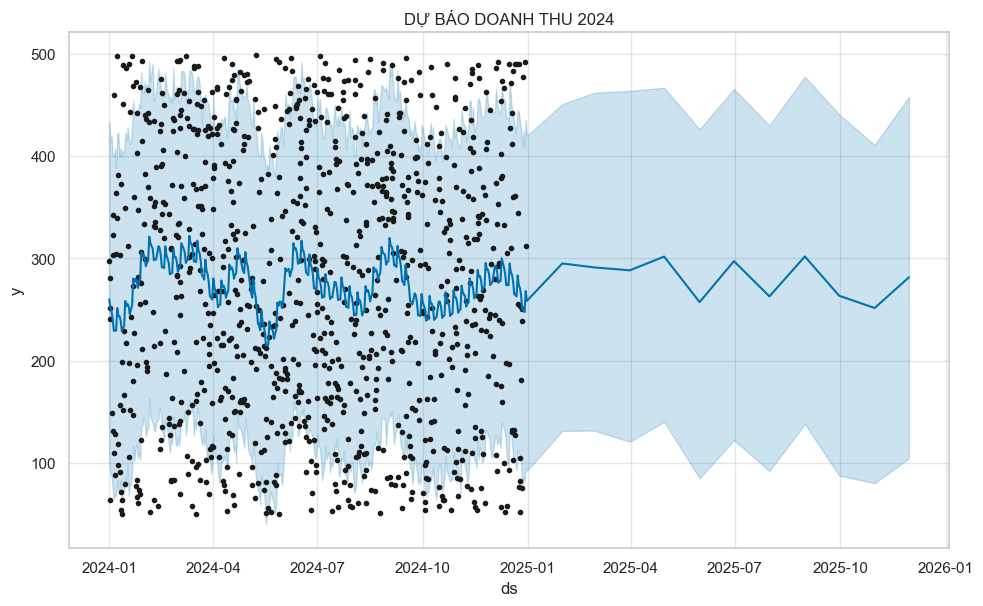


 Dự đoán doanh thu 12 kỳ tiếp theo:


,Thời gian,Dự đoán trung bình,Khoảng dưới,Khoảng trên
344,2024-12-31,258.541821,92.356413,419.798710
345,2025-01-31,295.107408,131.567272,450.753519
346,2025-02-28,291.243807,131.790243,462.032227
347,2025-03-31,288.414994,120.937934,463.808065
348,2025-04-30,301.829992,140.435220,466.776614
349,2025-05-31,257.358572,85.066717,426.154176
350,2025-06-30,297.392844,122.539987,465.630436
351,2025-07-31,262.983636,92.304076,429.999014
352,2025-08-31,301.925048,138.233970,477.633226
353,2025-09-30,263.579259,87.804360,440.606028



📊 Hiệu quả mô hình Prophet (Trên Dữ liệu Huấn luyện):
MAE  (Lỗi Tuyệt đối Trung bình): 111.56
RMSE (Căn bậc hai Lỗi Bình phương): 129.54
R²   (Hệ số Xác định): 0.029
MAPE (Phần trăm Lỗi Tuyệt đối): 67.90%


In [19]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"\nĐANG DỰ ĐOÁN DOANH THU 2025...")

df_prophet_train = df_prophet_main.rename(columns={'Time_of_Purchase': 'ds', 'Purchase_Amount': 'y'})

model = Prophet(yearly_seasonality=True, weekly_seasonality=True,changepoint_prior_scale=0.2,)
regressor = [
    "Frequency_of_Purchase",
    "Product_Rating",
    ]
for r in regressor:
    model.add_regressor(r)
    
model.fit(df_prophet_train)
future = model.make_future_dataframe(periods=12, freq ="M")

for r in regressor:
    # Chiến lược khắc phục lỗi: Gán giá trị trung bình lịch sử cho tương lai
    # Trong thực tế, bạn nên có một chiến lược dự kiến tốt hơn.
    
    # Lấy giá trị trung bình từ dữ liệu huấn luyện
    mean_val = df_prophet_train[r].mean() 
    
    # Gán giá trị trung bình cho toàn bộ 365 ngày dự đoán trong DataFrame 'future'
    future[r] = mean_val
    print(f"  - Đã gán {r} = {mean_val:.2f} cho khung thời gian tương lai.")
forecast = model.predict(future)

fig = model.plot(forecast)
plt.title('DỰ BÁO DOANH THU 2024')
plt.show()



# Lấy 12 dòng dự đoán cuối cùng để hiển thị (ví dụ: 12 tháng)
future_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
future_forecast.columns = ['Thời gian', 'Dự đoán trung bình', 'Khoảng dưới', 'Khoảng trên']
print("\n Dự đoán doanh thu 12 kỳ tiếp theo:")
display(future_forecast)

# **Đánh giá trên Dữ liệu Lịch sử**

# Ghép dữ liệu thực tế (df_prophet_train) và dự đoán (forecast)
# Lưu ý: Cột 'y' (thực tế) chỉ có trong df_prophet_train.
# Cột 'yhat' (dự đoán) có trong forecast.
df_eval = df_prophet_train.merge(forecast[['ds', 'yhat']], on='ds', how='left')

# Chỉ giữ phần giao nhau (dữ liệu thực tế có) và loại bỏ các hàng NaN (chỉ có trong tương lai)
df_eval = df_eval.dropna(subset=['y', 'yhat'])

# Tính các chỉ số đánh giá
# df_eval['y'] là giá trị thực tế, df_eval['yhat'] là giá trị dự đoán
mae = mean_absolute_error(df_eval['y'], df_eval['yhat'])
rmse = np.sqrt(mean_squared_error(df_eval['y'], df_eval['yhat']))
r2 = r2_score(df_eval['y'], df_eval['yhat'])
# Tính MAPE thủ công
mape = np.mean(np.abs((df_eval['y'] - df_eval['yhat']) / df_eval['y'])) * 100

print("\n📊 Hiệu quả mô hình Prophet (Trên Dữ liệu Huấn luyện):")
print(f"MAE  (Lỗi Tuyệt đối Trung bình): {mae:,.2f}")
print(f"RMSE (Căn bậc hai Lỗi Bình phương): {rmse:,.2f}")
print(f"R²   (Hệ số Xác định): {r2:.3f}")
print(f"MAPE (Phần trăm Lỗi Tuyệt đối): {mape:,.2f}%")

# Đề xuất

# 1. Hạn chế trong quá trình thực hiện

Trong quá trình triển khai mô hình Prophet dự đoán doanh thu theo thời gian từ tập dữ liệu Ecommerce_Consumer_Behavior_Analysis_Data.csv, nhóm nhận thấy một số hạn chế chính sau:

### 1. Dữ liệu không đầy đủ hoặc không đều theo thời gian

Biến Time_of_Purchase có thể không phân bố đều (ví dụ: nhiều ngày không có giao dịch).

Prophet hoạt động tốt nhất với dữ liệu chuỗi thời gian có độ liên tục ổn định.

### 2. Dữ liệu doanh thu (Purchase_Amount) không phản ánh doanh thu thực tế

Cột này chỉ đại diện cho mức chi tiêu của từng giao dịch, không phải tổng doanh thu hằng ngày/tháng.

Việc gộp hoặc trung bình có thể làm mất thông tin chi tiết, khiến dự đoán không chính xác.

### 3. Thiếu các biến ngoại sinh quan trọng

Prophet có thể tận dụng biến ngoại sinh như Promotion, Marketing_Spend, Holiday, Website_Visits...
→ Tuy nhiên, tập dữ liệu hiện tại chưa có các biến này, khiến mô hình chưa thể nắm bắt được ảnh hưởng mùa vụ, khuyến mãi, hay hành vi thị trường.

### 4. Sai số mô hình còn cao

Chỉ số R² = 0.029 cho thấy mô hình chưa giải thích được biến động doanh thu tốt.

MAPE = 67.9% là mức khá cao, chứng tỏ độ chính xác còn hạn chế.

Đề xuất hướng cải thiện mô hình dự đoán doanh thu

# 2. Đề xuất hướng cải thiện 
Trong quá trình triển khai mô hình Prophet để dự đoán doanh thu, nhóm nhận thấy một số hạn chế nhất định ảnh hưởng đến độ chính xác và khả năng tổng quát hóa của mô hình. Dựa trên kết quả đánh giá, nhóm đề xuất một số hướng cải thiện như sau:
### 1. Bổ sung dữ liệu doanh thu thực tế:
Hiện tại mô hình sử dụng giá trị Purchase_Amount ở mức giao dịch cá nhân. Việc thay thế hoặc tổng hợp dữ liệu này thành doanh thu tổng hợp theo ngày hoặc theo tháng sẽ giúp mô hình phản ánh đúng hơn xu hướng tài chính thực tế của doanh nghiệp.
→ Lợi ích: Cải thiện khả năng học xu hướng và mùa vụ dài hạn, giảm nhiễu do biến động cá nhân.

### 2. Làm sạch và nội suy dữ liệu thời gian:
Trong tập dữ liệu hiện tại, một số mốc thời gian bị thiếu hoặc không đồng đều. Việc sử dụng các phương pháp nội suy dữ liệu (interpolation) hoặc tái mẫu hóa (resampling) theo chu kỳ ngày/tháng giúp Prophet hoạt động ổn định hơn.
→ Lợi ích: Đảm bảo chuỗi thời gian liên tục, giúp mô hình học được các mô hình mùa vụ và xu hướng chính xác hơn.

### 3. Tạo thêm các biến ngoại sinh (External Regressors):
Prophet cho phép thêm các biến đầu vào bổ sung để cải thiện khả năng dự đoán. Một số biến có thể được khai thác thêm gồm:

Number_of_Visitors: lượng khách truy cập trang web/ngày;

Discount_Rate: tỷ lệ giảm giá trung bình theo ngày;

Ad_Spend: chi phí quảng cáo;

Holiday: biến chỉ định ngày lễ hoặc sự kiện đặc biệt.
→ Lợi ích: Giúp mô hình hiểu rõ hơn tác động của các chiến dịch marketing, khuyến mãi, hoặc mùa vụ tiêu dùng.

### 4. Kết hợp Prophet với Machine Learning (Hybrid Model):
Sau khi Prophet dự báo xu hướng chính (trend và seasonality), có thể dùng Random Forest hoặc XGBoost để học phần sai số (residuals).
→ Lợi ích: Mô hình lai (Hybrid Prophet + ML) giúp khắc phục điểm yếu của Prophet trong việc dự đoán các biến động phi tuyến và đột biến bất thường.

### 5. Tối ưu tham số Prophet:
Thực hiện Grid Search hoặc Bayesian Optimization để tìm ra bộ tham số tốt nhất cho các biến:

changepoint_prior_scale: kiểm soát độ linh hoạt của xu hướng;

seasonality_prior_scale: kiểm soát cường độ của thành phần mùa vụ;

seasonality_mode: lựa chọn giữa additive hoặc multiplicative.
→ Lợi ích: Tăng khả năng thích ứng của mô hình với dữ liệu thực tế, cân bằng giữa độ chính xác và khả năng khái quát.

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Giữ lại các dòng hợp lệ
df_corr = df[['Purchase_Amount', 'Brand_Loyalty']].dropna()

# Nếu Purchase_Amount là chuỗi tiền tệ thì cần chuyển đổi
if df_corr['Purchase_Amount'].dtype == 'object':
    df_corr['Purchase_Amount'] = df_corr['Purchase_Amount'].replace('[\$,]', '', regex=True).astype(float)

# Kiểm định Pearson (tuyến tính)
pear_corr, pear_p = pearsonr(df_corr['Purchase_Amount'], df_corr['Brand_Loyalty'])
print(f" Hệ số tương quan Pearson: {pear_corr:.3f},  P-value: {pear_p:.5f}")

# Kiểm định Spearman (nếu mối quan hệ phi tuyến)
spear_corr, spear_p = spearmanr(df_corr['Purchase_Amount'], df_corr['Brand_Loyalty'])
print(f" Hệ số tương quan Spearman: {spear_corr:.3f},  P-value: {spear_p:.5f}")


📈 Hệ số tương quan Pearson: -0.074,  P-value: 0.01890
📉 Hệ số tương quan Spearman: -0.074,  P-value: 0.01892


/Library/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4776: RuntimeWarning: overflow encountered in vecdot
  r = xp.vecdot(xm / normxm, ym / normym, axis=axis)


- Kết quả kiểm định cho thấy giữa Brand_Loyalty (độ trung thành thương hiệu) và Purchase_Amount (số tiền chi tiêu) có mối quan hệ ngược chiều rất yếu (r = -0.074).
- Dù giá trị p < 0.05 cho thấy mối tương quan này có ý nghĩa thống kê, nhưng độ mạnh của mối liên hệ gần như không đáng kể về mặt thực tế.
- Nói cách khác, độ trung thành thương hiệu không ảnh hưởng đáng kể đến mức chi tiêu của khách hàng trong tập dữ liệu này.